# Zadanie 3: Sieć MLP
Implementacja sieci neuronowej MLP w PyTorch na zbiorze CIFAR-10.

## 1. Przygotowanie środowiska

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


## 2. Analiza zbioru danych
Zbiór zawiera 60 tysięcy obrazów RGB o wymiarach 32x32 piksele (pobrane dane nie widnieją w repozytorium ze względu na to że są zbyt duże).

Files already downloaded and verified
Files already downloaded and verified
Kształt pojedynczego obrazu: torch.Size([3, 32, 32])
Zakres wartości pikseli: -0.69 do 0.98


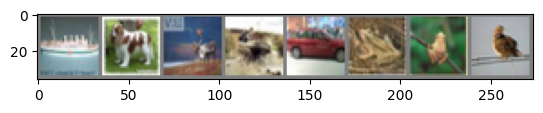

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"Kształt pojedynczego obrazu: {images[0].shape}")
print(f"Zakres wartości pikseli: {images[0].min().item():.2f} do {images[0].max().item():.2f}")
imshow(torchvision.utils.make_grid(images[:8]))

## 3. Implementacja architektury MLP

In [60]:
class CIFAR10_MLP(nn.Module):
    def __init__(self, hidden_layers=[512, 256], dropout_p=0.0):
        super(CIFAR10_MLP, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        input_size = 3 * 32 * 32
        
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            input_size = hidden_size
            
        layers.append(nn.Linear(input_size, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

## 4. Funkcja treningowa

In [61]:
def train_model(model, loader_train, loader_test, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for imgs, lbls in loader_train:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
            
        model.eval()
        t_correct = 0
        t_total = 0
        with torch.no_grad():
            for imgs, lbls in loader_test:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs.data, 1)
                t_total += lbls.size(0)
                t_correct += (predicted == lbls).sum().item()
        
        history['train_loss'].append(running_loss / len(loader_train))
        history['train_acc'].append(100 * correct / total)
        history['test_acc'].append(100 * t_correct / t_total)
        
    return history

## 5. Eksperymenty
Pętla 54 eksperymentów dla iloczynu kartezjańskiego:
1. Learning Rate (0.01, 0.001, 0.0001)
2. Batch Size (32, 64, 128)
3. Hidden Layers (512-256, 256-128)
4. Dropout (0.0, 0.25, 0.5)

In [ ]:
params_config = {
    'lr': [0.01, 0.001, 0.0001],
    'batch_size': [32, 64, 128],
    'hidden_layers': [[512, 256], [256, 128]],
    'dropout': [0.0, 0.25, 0.5]
}

combinations = [{}]
for key, values in params_config.items():
    combinations = [
        {**dict_copy, key: value} 
        for dict_copy in combinations 
        for value in values
    ]

root_results_dir = "Eksperymenty"
if not os.path.exists(root_results_dir):
    os.makedirs(root_results_dir)

for i, config in enumerate(combinations):
    arch_str = "-".join(map(str, config['hidden_layers']))
    folder_name = f"exp_{i}_LR{config['lr']}_BS{config['batch_size']}_DO{config['dropout']}_HiLa{arch_str}"
    exp_dir = os.path.join(root_results_dir, folder_name)
    
    if not os.path.exists(exp_dir):
        os.makedirs(exp_dir)
        
    print(f"[{i+1}/{len(combinations)}]")

    train_loader_exp = torch.utils.data.DataLoader(trainset, batch_size=config['batch_size'], shuffle=True)
    test_loader_exp = torch.utils.data.DataLoader(testset, batch_size=config['batch_size'], shuffle=False)

    model = CIFAR10_MLP(hidden_layers=config['hidden_layers'], dropout_p=config['dropout'])
    hist = train_model(model, train_loader_exp, test_loader_exp, epochs=10, lr=config['lr'])

    plt.figure(figsize=(10, 5))
    plt.plot(hist['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(hist['test_acc'], label='Test Accuracy', color='green')
    plt.title(f"Wyniki: {folder_name}")
    plt.xlabel("Epoka")
    plt.ylabel("Dokładność (%)")
    plt.legend()
    plt.grid(True)
    
    plt.savefig(os.path.join(exp_dir, "wykres_accuracy.png"))
    plt.close()

    df = pd.DataFrame(hist)
    df.to_csv(os.path.join(exp_dir, "dane_treningowe.csv"), index=False)

print("Gotowe.")

## 6. Metryki i Analiza błędów

              precision    recall  f1-score   support

       plane       0.61      0.57      0.59      1000
         car       0.67      0.56      0.61      1000
        bird       0.44      0.39      0.41      1000
         cat       0.35      0.35      0.35      1000
        deer       0.41      0.54      0.46      1000
         dog       0.46      0.45      0.45      1000
        frog       0.61      0.59      0.60      1000
       horse       0.69      0.54      0.60      1000
        ship       0.56      0.74      0.64      1000
       truck       0.60      0.58      0.59      1000

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.54      0.53      0.53     10000



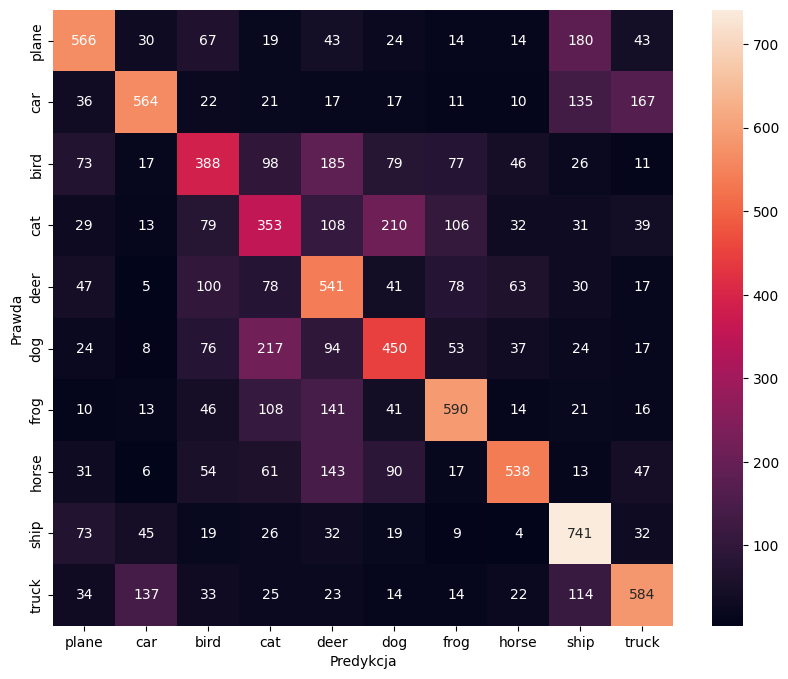

In [ ]:
model_final.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, lbls in testloader:
        imgs = imgs.to(device)
        outputs = model_final(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(lbls.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predykcja')
plt.ylabel('Prawda')
plt.show()

## 7. Najciekawsze modele

In [ ]:
results_summary = []
root_dir = "Eksperymenty"

for folder in os.listdir(root_dir):
    csv_path = os.path.join(root_dir, folder, "dane_treningowe.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        last_row = df.iloc[-1]
        results_summary.append({
            'folder': folder,
            'train_acc': last_row['train_acc'],
            'test_acc': last_row['test_acc'],
            'loss': last_row['train_loss'],
            'gap': last_row['train_acc'] - last_row['test_acc']
        })

summary_df = pd.DataFrame(results_summary)

best_model = summary_df.loc[summary_df['test_acc'].idxmax()]
worst_model = summary_df.loc[summary_df['test_acc'].idxmin()]
most_overfitted = summary_df.loc[summary_df['gap'].idxmax()]
most_unstable = summary_df.loc[summary_df['loss'].idxmax()]

print("NAJCIEKAWSZE MODELE")
print(f"1. NAJLEPSZY: {best_model['folder']} | Acc: {best_model['test_acc']:.2f}%")
print(f"2. NAJGORSZY (Brak nauki): {worst_model['folder']} | Acc: {worst_model['test_acc']:.2f}%")
print(f"3. OVERFITTING (Luka): {most_overfitted['folder']} | Różnica: {most_overfitted['gap']:.2f}%")
print(f"4. NAJBARDZIEJ NIESTABILNY: {most_unstable['folder']} | Loss: {most_unstable['loss']:.4f}")

NAJCIEKAWSZE MODELE
1. NAJLEPSZY: exp_43_LR0.0001_BS64_DO0.25_HiLa512-256 | Acc: 55.35%
2. NAJGORSZY (Brak nauki): exp_1_LR0.01_BS32_DO0.25_HiLa512-256 | Acc: 10.00%
3. OVERFITTING (Luka): exp_30_LR0.001_BS128_DO0.0_HiLa512-256 | Różnica: 19.46%
4. NAJBARDZIEJ NIESTABILNY: exp_5_LR0.01_BS32_DO0.5_HiLa256-128 | Loss: 2.3044


## 8. Wnioski
### Najlepszy model
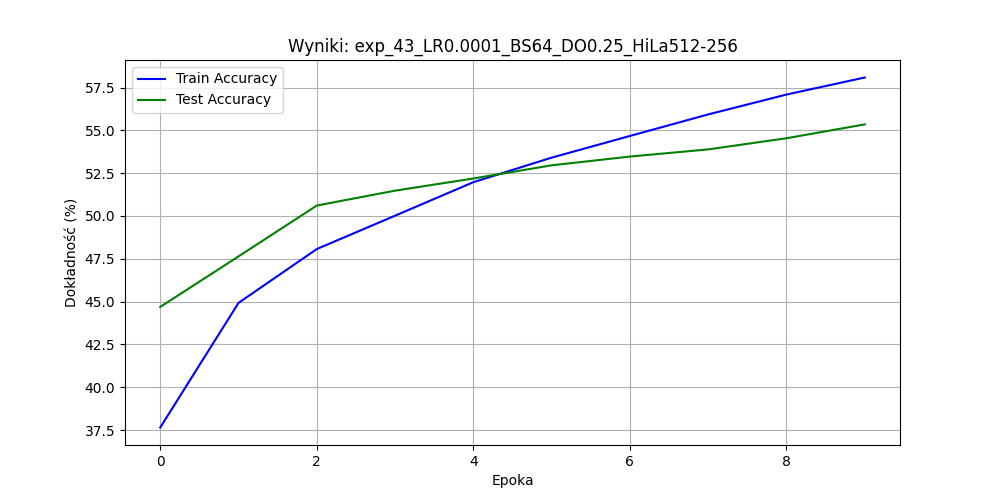

Parametry:
- Learning Rate: 0.0001
- Batch Size: 64
- Dropout: 0.25
- Neurony: 512-256

Dokładność 55,35% jest dobrym wynikiem dla architektury MLP w zbiorze CIFAR-10. Sieć ta ma ograniczoną zdolność do rozpoznawania złożonych obiektów (w przeciwieństwie do CNN). Wynik potwierdza poprawność dobranych hiperparametrów, w tym niskiego współczynnika uczenia oraz warstwy dropout, która ograniczyła przeuczanie modelu.

### Najgorszy model
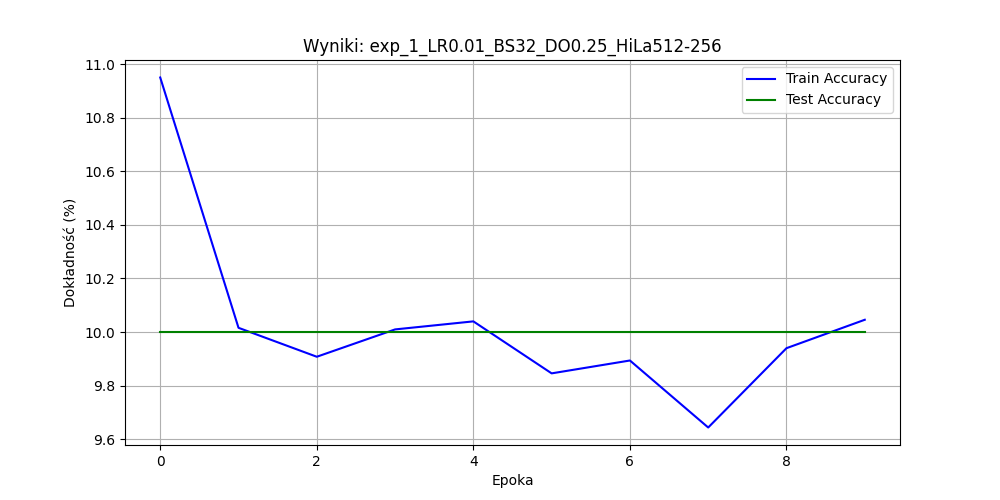

Parametry:
- Learning Rate: 0.01
- Batch Size: 32
- Dropout: 0.25
- Neurony: 512-256

Dokładność na poziomie 10% przy 10 klasach oznacza, że model zgaduje totalnie losowo. Jest to spowodowane rozbieżnością gradientu przez Learning Rate na poziomie 0.01 i Batch Size na poziomie 32 co sprawiło, że model nie był w stanie wyłapać żadnych wzorców.

### Overfitting
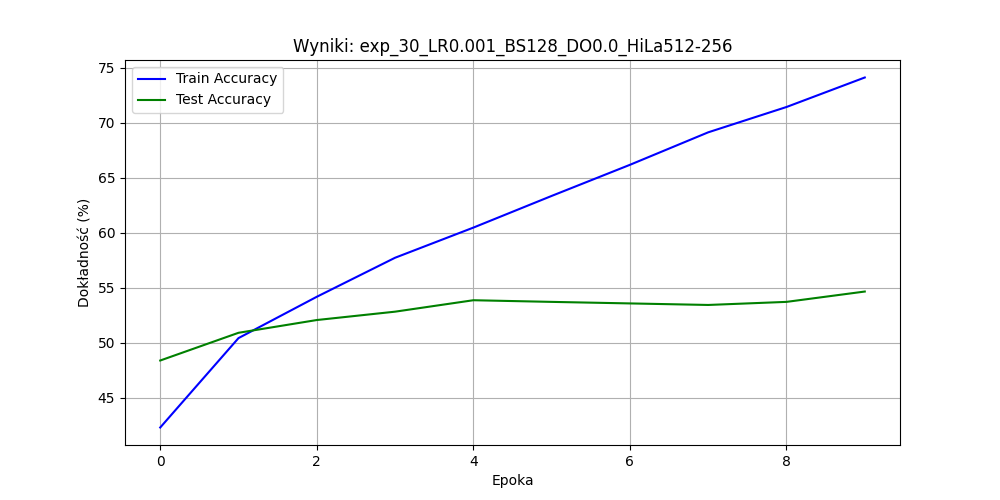

Parametry:
- Learning Rate: 0.001
- Batch Size: 128
- Dropout: 0.0
- Neurony: 512-256

Różnica 20% między treningiem a testem wynika z braku regularyzacji (dropout na poziomie 0.0). Sieć o dużej pojemności (512-256) nauczyła się na pamięć pikseli ze zbioru treningowego zamiast nauczyć się jak wygląda poszczególny obiekt.

### Najbardziej niestabilny

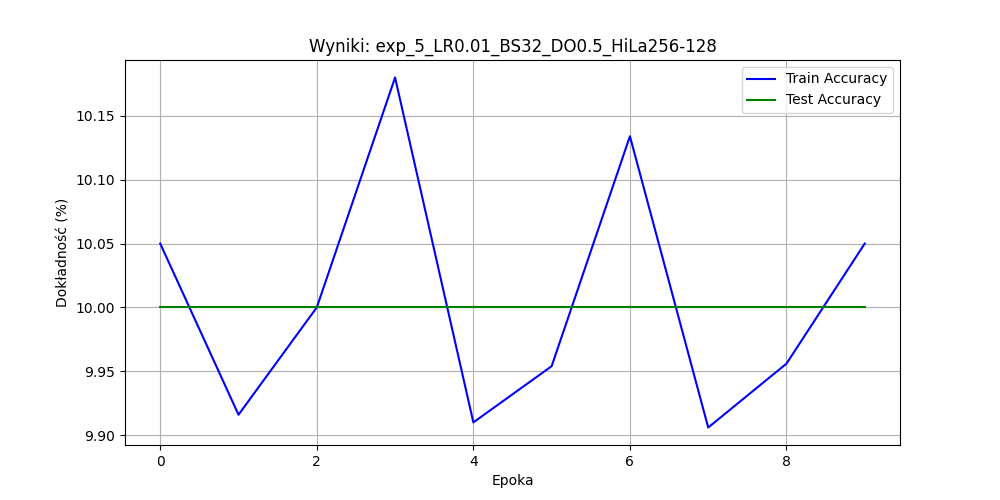

Parametry:
- Learning Rate: 0.01
- Batch Size: 32
- Dropout: 0.5
- Neurony: 256-128

Połączenie wysokiego Learning Rate (0.01) z silnym Dropout (0.5) sprawiło, że sieć traciła zbyt dużo informacji podczas każdej iteracji i nie mogła się skutecznie nauczyć. Mniejsza architektura (256-128) w połączeniu z agresywnym dropoutem ma za mało zasobów, by przetrwać tak dużą redukcję danych podczas trenowania.

### Reszta danych oraz wykresów poszczególnych modeli jest dostępna do przejrzenia w folderze 'Eksperymenty'.
